In [4]:
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return pd.DataFrame()

In [6]:
Rosedata2_df = read_csv_to_dataframe("Occurrence_ext.csv")
print(Rosedata2_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1585 entries, 0 to 1584
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   collection_code           1585 non-null   object
 1   event_id                  1585 non-null   object
 2   catalog_number            1585 non-null   int64 
 3   occurrence_id             1585 non-null   object
 4   scientific_name           1585 non-null   object
 5   identification_qualifier  234 non-null    object
 6   individual_count          1585 non-null   int64 
 7   class                     1585 non-null   object
 8   feeding_type              1585 non-null   object
 9   life_mode                 1585 non-null   object
 10  habitat                   1585 non-null   object
dtypes: int64(2), object(9)
memory usage: 136.3+ KB
None


In [7]:
Rosedata2_df["individual_count"].describe()

count    1585.000000
mean        4.487697
std         9.262243
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       121.000000
Name: individual_count, dtype: float64

In [8]:
Rosedata2_df.groupby("habitat")["individual_count"].describe()

,count,mean,std,min,25%,50%,75%,max
habitat,,,,,,,,
coral reef,963.0,3.981308,7.411548,1.0,1.0,2.0,4.0,82.0
seagrass,622.0,5.271704,11.520274,1.0,1.0,2.0,5.0,121.0


<function matplotlib.pyplot.show(close=None, block=None)>

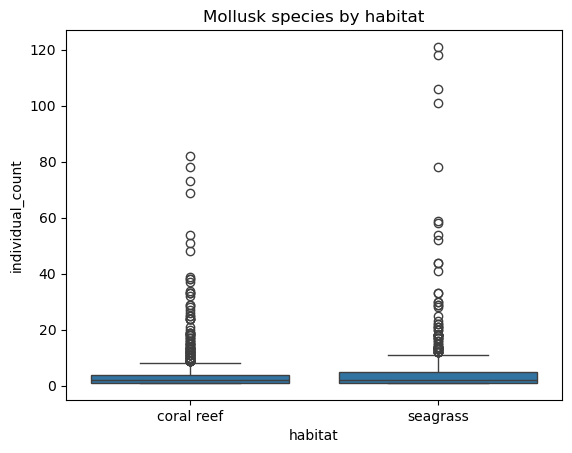

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="habitat", y="individual_count", data= Rosedata2_df)
plt.title("Mollusk species by habitat")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

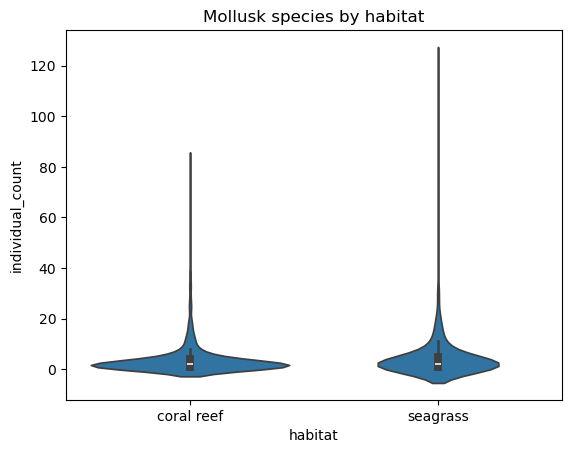

In [10]:
sns.violinplot(x="habitat", y="individual_count", data= Rosedata2_df)
plt.title("Mollusk species by habitat")
plt.show

In [11]:
import numpy as np
from scipy.stats import entropy

In [13]:
def detailed_shannon(group):
    total = group["individual_count"].sum()
    props = group["individual_count"] / total
    props = props[props > 0]
    shannon = -sum(props * np.log(props))

    return pd.Series({
        "Richness": group["scientific_name"].nunique(),
        "Total abundance": total,
        "Shannon": shannon,
        "Evenness": shannon / np.log(len(props)) if len(props) > 0 else 0
    })


results = (
    Rosedata2_df.drop(columns="habitat")
    .groupby(Rosedata2_df["habitat"], group_keys=False)
    .apply(detailed_shannon)
)

<function matplotlib.pyplot.show(close=None, block=None)>

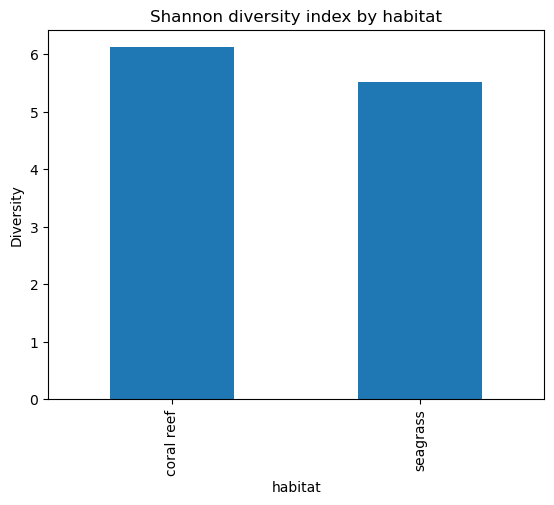

In [14]:
results.reset_index().plot.bar(x="habitat", y="Shannon", legend=False)
plt.title("Shannon diversity index by habitat")
plt.ylabel("Diversity")
plt.show